In [4]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

In [5]:
df = pd.read_csv('smartcart_customers.csv')

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [7]:
df.shape

(2240, 22)

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle the Missing Values

In [9]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## 2. Feature Engineering

In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

In [12]:
# Age
df['Age'] = 2026 - df['Year_Birth']

In [13]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
ref_date = df["Dt_Customer"].max()
df['Customer_Tenure_days'] = (ref_date - df['Dt_Customer']).dt.days

In [14]:
# Spending
df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [15]:
# Children
df["Total_Children"] = df['Kidhome'] + df['Teenhome']

In [16]:
# Education

df["Education"] = df["Education"].replace({
        "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
        "Graduation" : "Graduate",
        "Master" : "Postgraduate", "PhD" : "Postgraduate"

})

In [17]:
# Marital Status
df['Living_With'] = df["Marital_Status"].replace({
        "Married" : "Partner", "Together" : "Partner",
        "Single" : "Alone", "Divorced" : "Alone",
        "Widow" : "Alone", "Absurd" : 'Alone', "YOLO" : 'Alone'
})

In [18]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


## 3. Drop Columns

In [20]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [21]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ['MntWines' , 'MntFruits' ,'MntMeatProducts','MntFishProducts', 'MntSweetProducts' , 'MntGoldProds']

cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [22]:
df_cleaned.shape

(2240, 15)

In [23]:
df.shape

(2240, 27)

In [24]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers

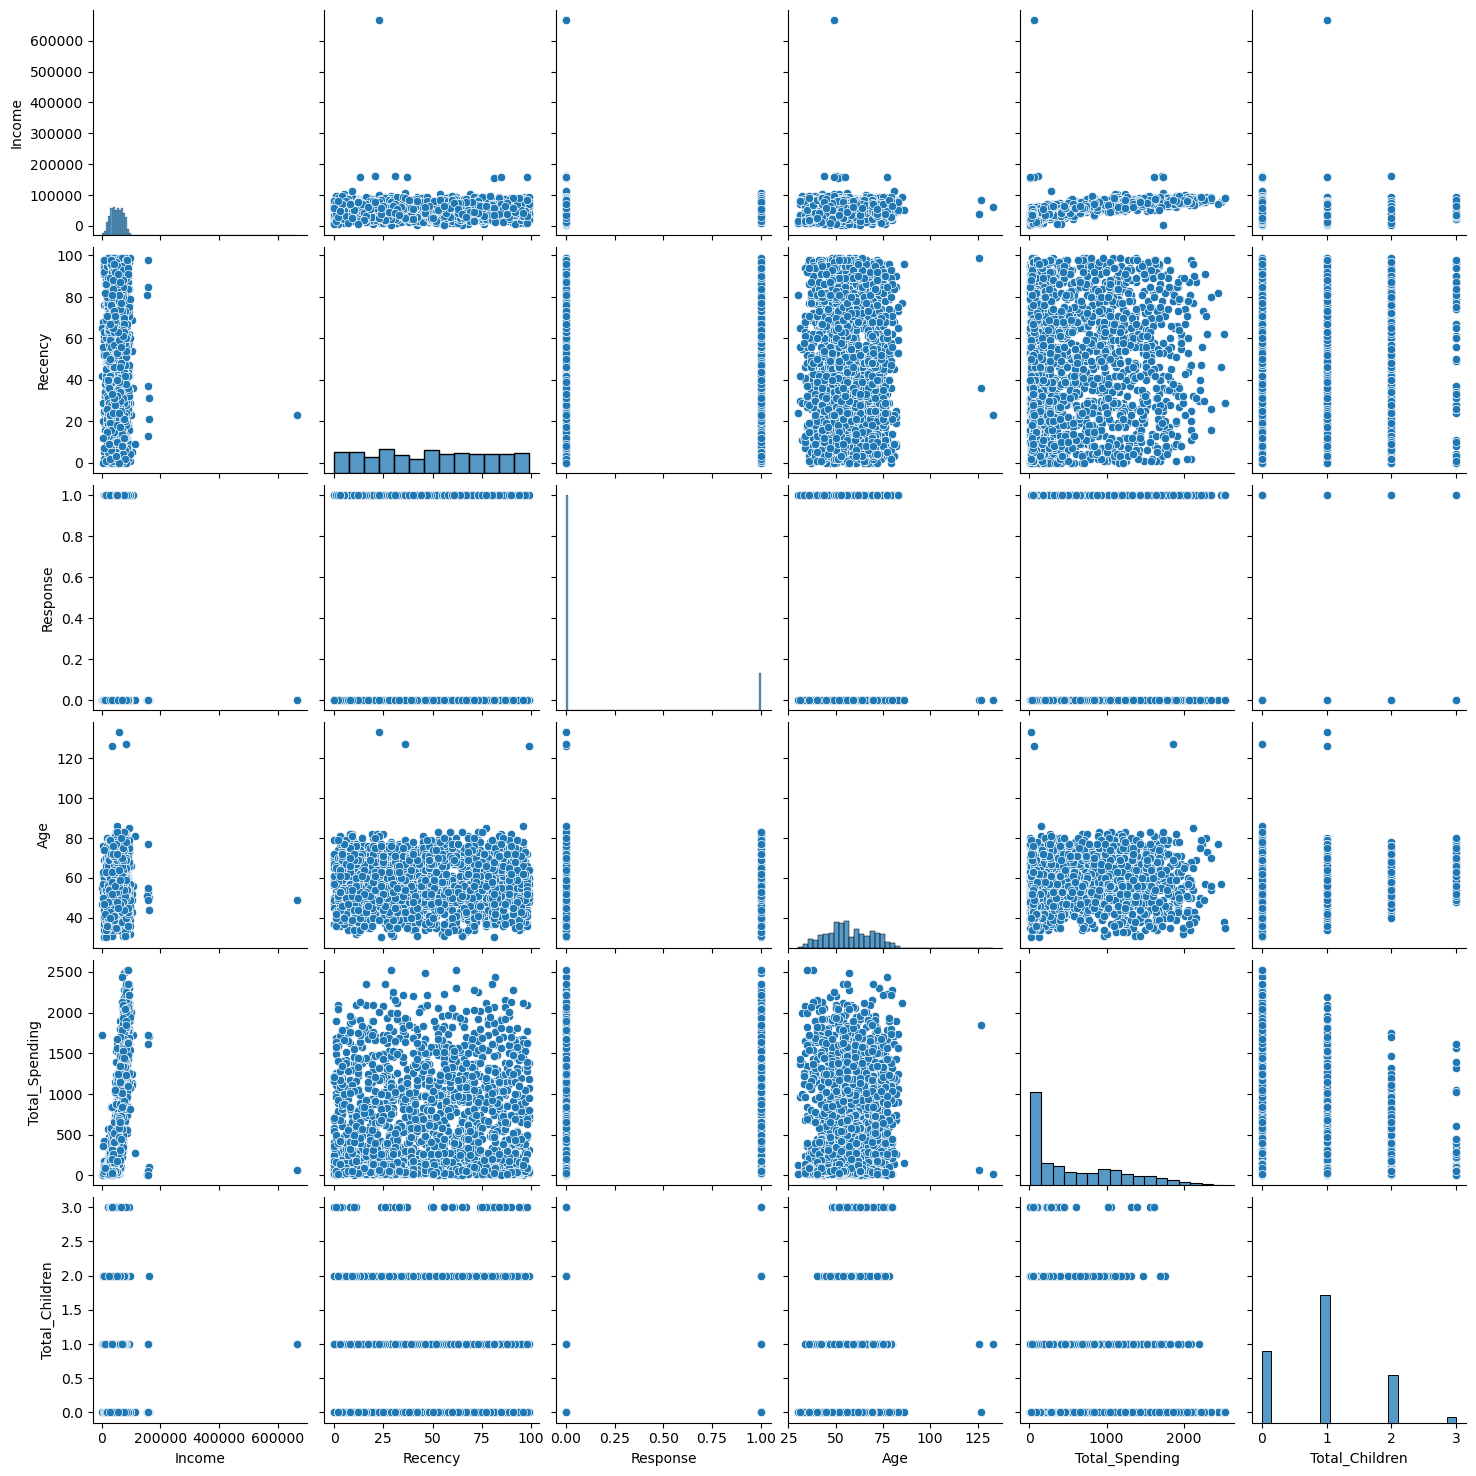

In [25]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

# Relative plots of some features - Pair plot
sns.pairplot(df_cleaned[cols])

In [26]:
# remove outliers

print("Data size with outliers: ",len(df_cleaned))
df_cleaned = df_cleaned[ (df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[ (df_cleaned["Income"]<600_000)]
print("Data size without outliers: ",len(df_cleaned))

Data size with outliers:  2240
Data size without outliers:  2236


## Heatmap for Correlation

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

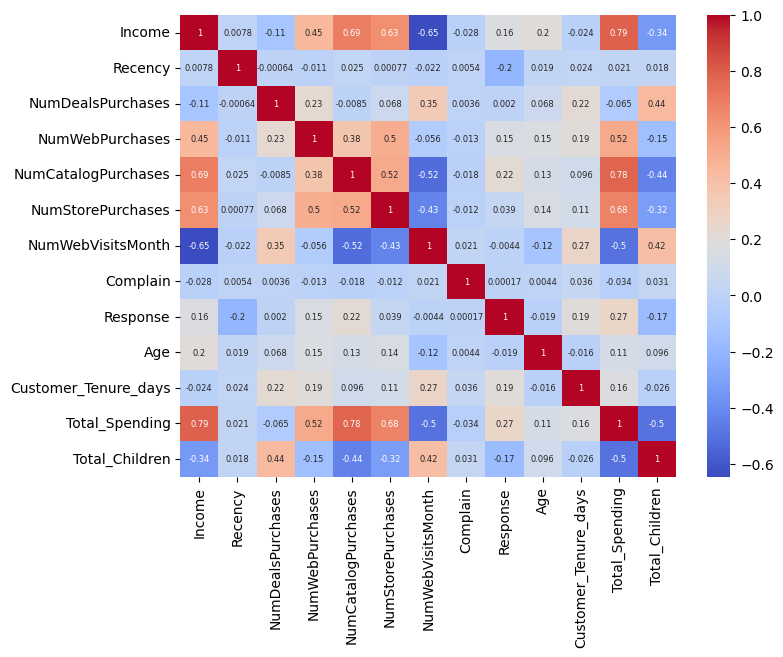

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap='coolwarm'
)


In [30]:
df_cleaned.shape

(2236, 15)

## Encoding

In [31]:
from sklearn.preprocessing import OneHotEncoder

In [32]:
ohe = OneHotEncoder()
cat_cols  = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [33]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [34]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [35]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis = 1)

In [36]:
df_encoded.shape

(2236, 18)

In [37]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
X = df_encoded

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualize

In [41]:
X_scaled.shape

(2236, 18)

In [42]:
# 2D
from sklearn.decomposition import PCA

In [43]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [44]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

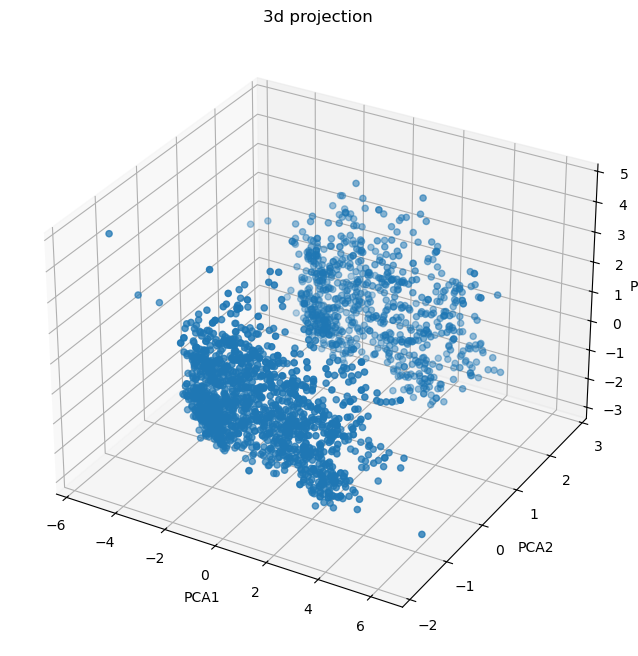

In [45]:
#  plot
fig = plt.figure(figsize=(8,8))
ax  = fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K value
## 1. Elbow Method

In [46]:
! pip install kneed

In [47]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks t

In [48]:
# from sklearn.cluster import KMeans
# from kneed import KneeLocator
# wcss = []
# for k in range(1,11):
#         kmeans = KMeans(n_clusters=k,random_state=42)
#         kmeans.fit_predict(X_pca)
#         wcss.append(kmeans.inertia_)


In [49]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [50]:
print("Best k = ",optimal_k)

Best k =  4


Text(0, 0.5, 'WCSS')

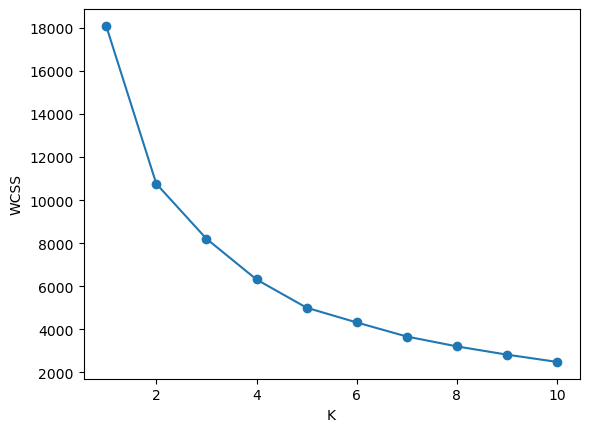

In [51]:
# plot
plt.plot(range(1,11),wcss,marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")

## 2. Silhouette Score

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks t

Text(0, 0.5, 'Silhouette Score')

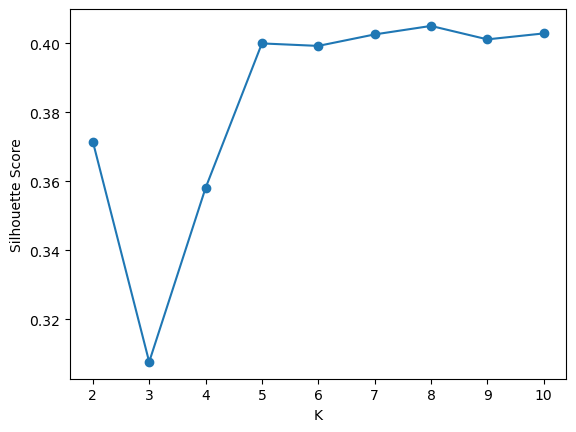

In [53]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
        kmeans = KMeans(n_clusters=k,random_state=42)
        labels = kmeans.fit_predict(X_pca)
        score = silhouette_score(X_pca,labels)
        scores.append(score)

# Plot
plt.plot(range(2,11),scores,marker = 'o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")       

Text(0, 0.5, 'Silhouette Score')

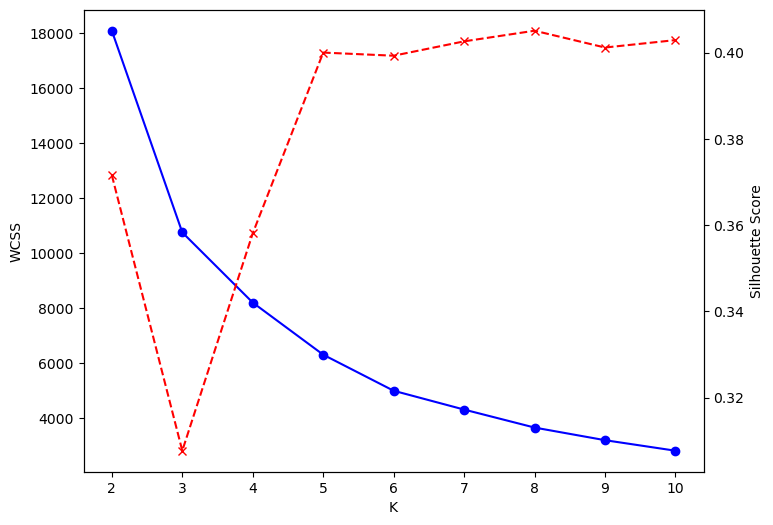

In [66]:
# Combined Plot
k_range = range(2,11)
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker='o',color='blue')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker = 'x',color = 'red',linestyle="--")
ax2.set_ylabel("Silhouette Score")



## Clustering

In [55]:
import os
os.environ["OMP_NUM_THREADS"] = "9"

from sklearn.cluster import KMeans

In [56]:
# K means

kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans  = kmeans.fit_predict(X_pca)

e:\DataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


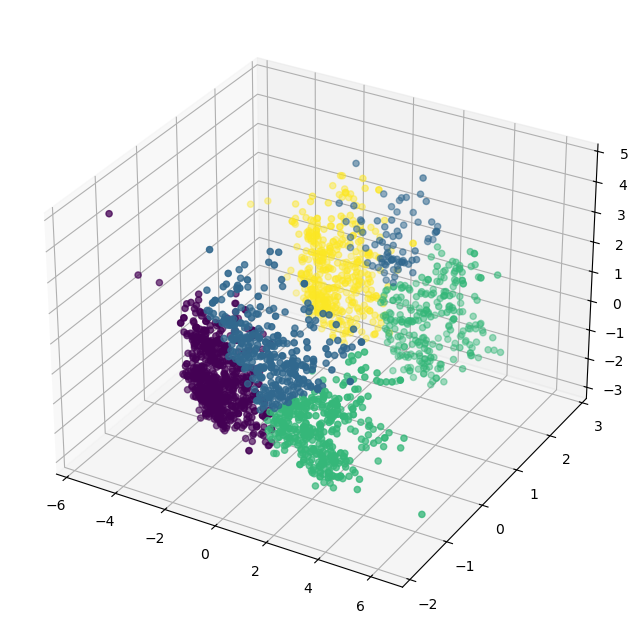

In [57]:
fig = plt.figure(figsize=(8,8))
ax  = fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

In [58]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [59]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

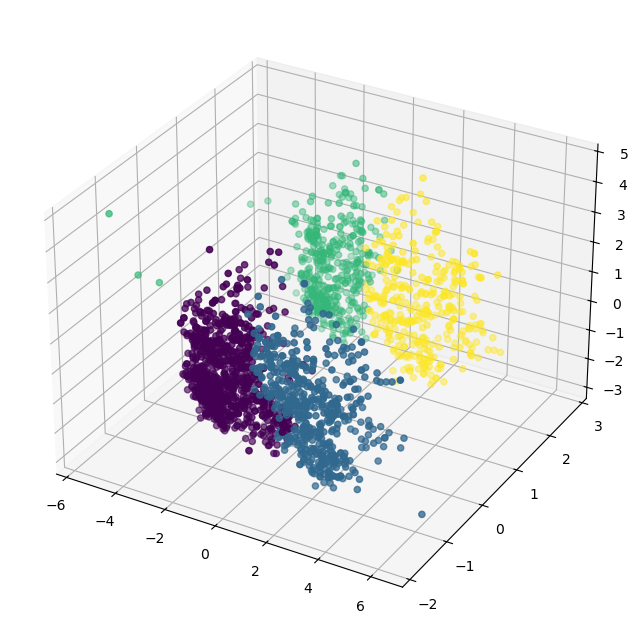

In [60]:
fig = plt.figure(figsize=(8,8))
ax  = fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

## Chareterization of Clusters

In [61]:
X['Clusters'] = labels_agg

In [62]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


<Axes: xlabel='Clusters', ylabel='count'>

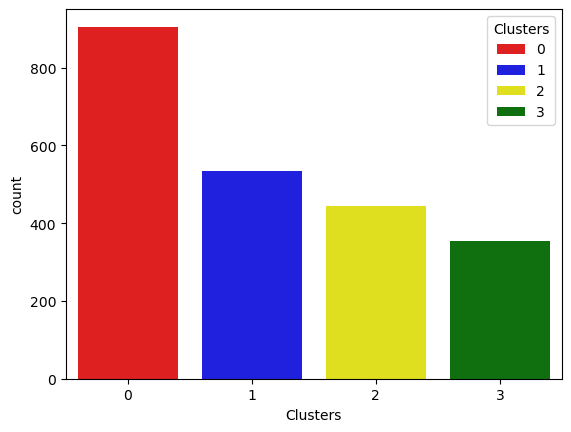

In [63]:
pal = ["red","blue",'yellow',"green"]
sns.countplot(x = X["Clusters"],palette=pal,hue=X["Clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

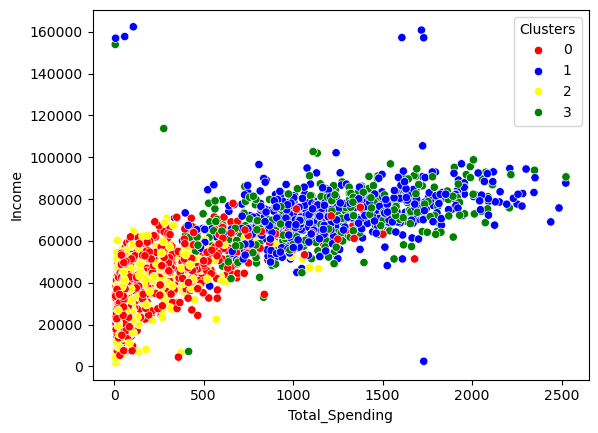

In [64]:
# income and Spending patterns

sns.scatterplot(x = X['Total_Spending'],y=X['Income'],hue = X['Clusters'],palette=pal)

In [65]:
# Cluster Summary

cluster_summary = X.groupby("Clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_days  Total_Spending  \
Clu